In [39]:
import pandas as pd
import numpy as np
from statsmodels.tsa.filters.hp_filter import hpfilter # Hodrick-Prescott
from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams
rcParams["figure.figsize"] = 7, 4

In [5]:
df = pd.read_csv("data/macrodata.csv", index_col=0, parse_dates=True)
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


<Axes: >

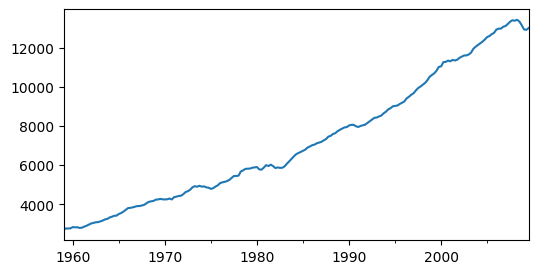

In [37]:
df["realgdp"].plot(figsize=(6,3))

In [16]:
gdp_cycle, gdp_trend = hpfilter(df["realgdp"], lamb=1600) # 1600 for quaterly data
df["trend"] = gdp_trend

<Axes: >

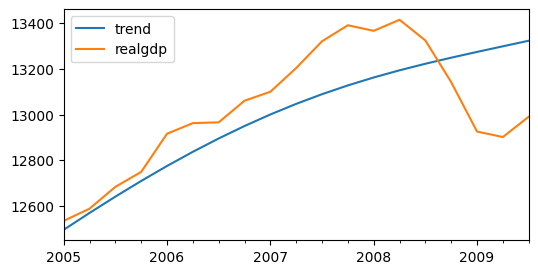

In [21]:
df[["trend", "realgdp"]]["2005":].plot(figsize=(6,3))

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Axes: xlabel='Month'>

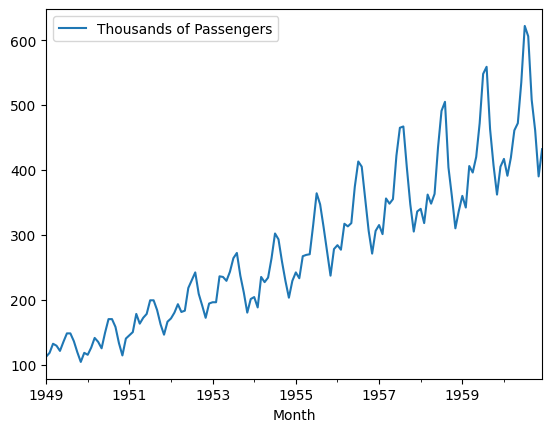

In [26]:
airline = pd.read_csv("data/airline_passengers.csv", index_col="Month", parse_dates=True)
airline.dropna(inplace=True)
display(airline.head())
airline.plot()

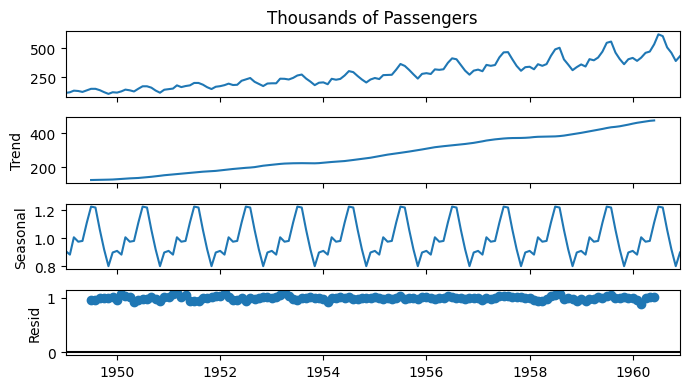

In [40]:
result = seasonal_decompose(airline["Thousands of Passengers"], model="multiplicative")
_ = result.plot()